In [1]:
#julia version:1.11.6
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using ProgressMeter
using PyCall


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
function ODE(N_cheb,Ro)
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    return u0,v0,w0,f,q,D,D2,x
end
function BF(N_cheb,Tw,Mr,u0,v0,w0,f,q,D,D2,x)
    gamma = 1.4
    sigma = 0.72
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"phy")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,z,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    sigma = 0.72
    gamma = 1.4
    # if Ro == -1
    #    A0,A1,A2 = Spatial_mode_BEK(-F,-G,-H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    # else 
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    A0_raw,A1_raw,A2_raw = assemble_mat(cof :: COF,D,D2,be,omega)
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    # end
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval
end

eigsol (generic function with 1 method)

In [3]:
N_cheb = 199
Ro = -1.0
Tw = 1.2
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = 0.07759
num = 1
omega = 0.0
data = [0 0 0 0 0]
R = 285.36
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = ODE(N_cheb,Ro)
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Tw,Mr,u0,v0,w0,f,q,D,D2,x)
# eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.4,num)

([0.0; -2.0324995192586855e-5; … ; 2.7861556664386805e-8; 2.7861556664386805e-8;;], [0.0; 2.581165001505874e-5; … ; -0.9999999637833137; -0.9999999637833137;;], [-8.11573660789083e-29; 1.2950555692813689e-6; … ; -0.8841279686598494; -0.8841279686598494;;], [1.2; 1.200002423616238; … ; 0.9996087182553752; 0.9996087182553752;;], [0.8333333333333334; 0.8333316502699005; … ; 1.0003914349059577; 1.0003914349059577;;], [0.0, 0.009599080739039737, 0.014397241162732631, 0.019194480223488807, 0.023990796880517803, 0.028786190099831112, 0.0335806588542449, 0.0383742021233827, 0.04316681889367806, 0.04795850815837734  …  40.37610590331143, 40.38010433293197, 40.384102762552516, 40.38810119217305, 40.392099621793605, 40.39609805141414, 40.400096481034694, 40.40409491065523, 40.40809334027578, 40.412091769896314], [-0.7999999999999999; -0.8000016157441587; … ; -0.6664058121702501; -0.6664058121702501;;], [1.6666666666666665; 1.6666700328003305; … ; 1.3883454420213543; 1.3883454420213543;;], [-2000.

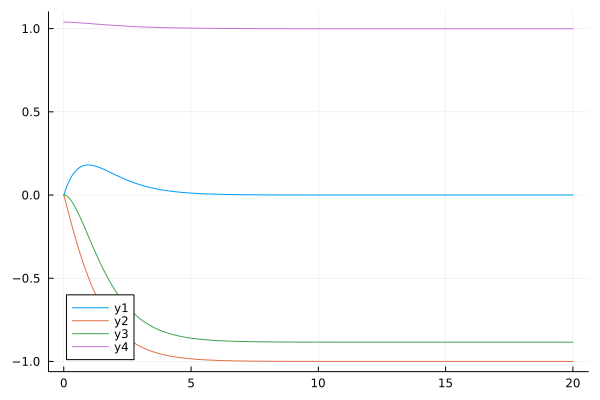

In [73]:
plot(x,F)
plot!(x,G)
plot!(x,H)
plot!(x,T)

In [71]:
writedlm("BASEFLOW_TW=1.04.dat",[x F G H T])

In [5]:
function cur(Tw,Mr,Ro,omega,R_ini,c_ini,be_ini)

    N_cheb = 199
    gamma = 1.4
    sigma = 0.72
    be_step = -0.0001
    num = 2
    Co = 2-Ro-Ro^2
    Ma = Mr/R_ini
    u0,v0,w0,f,q,D,D2,x = ODE(N_cheb,Ro)
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Tw,Mr,u0,v0,w0,f,q,D,D2,x)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
    if imag(eigval[1]) < 0
        for be = be_ini :  be_step : -0.5
            sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[2]))
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[2]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 && sig_last1 != 0 || sig_last2 * sig_now2 < 0 && sig_last2 != 0 
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : - be_step : 0.5
           sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[2]))
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[2]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 && sig_last1 != 0 || sig_last2 * sig_now2 < 0 && sig_last2 != 0 
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    end
    total = initial
    be = initial[3] - be_step
    dir = 0
    boundlen = 40
 # CACULATE

    while true
        index = findall(x->x==findmin([total[end,5],total[end,7]])[1],total[end,:])
        c = total[end,index[1] - 1]
        eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
        eigval_1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be - 0.0001,N_cheb,Ro,Co,D,D2,c,num)
        eigval_2 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be + 0.0001 * be_step,N_cheb,Ro,Co,D,D2,c,num)
        index1 = findmin(x-> (imag(x)) , eigval_1)[2]
        index2 = findmin(x-> (imag(x)) , eigval_2)[2]
        num = 1
        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <=2
            R_step = 0.25
        else
            R_step = 1
        end
        if (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) > 0) || (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) > 0) || dir == -1
            mode = 1
        elseif (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) < 0) || (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) < 0)
            mode = 2
        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 700

                Ma = Mr/R

                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]

                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0

                Ma = Mr/R
                
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end

        if mode == 1

            for R = total[end,2]: R_step : 700
                Ma = Mr/R

                if total[end,3] == be

                    break

                end 
                
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     

                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end
        c = total[end,4]
        Ma = Mr/total[end,2]
        eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2]+2,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
        sig = findmin(imag,eigval)[1]
        if size(total,1) > 10 &&total[end,3] != be 
            dir = -1 
            be_step = 0.0009
        else
            if sig > 0
                dir = -1
                be_step = 0.00075
            else
                dir = 1
                be_step = 0.00075
            end
        end
            be += dir * be_step
        filename = "ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Ma=$(Mr),Tw=$(Tw),Ro=$(Ro)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end
        if total[end,2] > 500 && size(total,1) > 30 
            break
        end
        # app = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat")
        # ori = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
        # if app[end,2] < ori[3,2]
        #     break
        # end
    end
end

cur (generic function with 1 method)

In [7]:
for omega in (0.0)
    for Tw in (1.04)
        for Mr in 0.3
            R_ini = 500
            c_ini = 0.05
            # be_ini = 1/(Tw*20)
            be_ini = 0.03
            Ro = -1
            cur(Tw,Mr,Ro,omega,R_ini,c_ini,be_ini)
        end
    end
end

In [ ]:
a = [1,4,5,2,1]
num = sum(x->x==10,a)